In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!mkdir -p /content/drive/MyDrive/kitti

In [ ]:
# Step 3: Download KITTI label files (contains ground truth bounding boxes)
!wget -P /content/drive/MyDrive/kitti https://s3.eu-central-1.amazonaws.com/avg-kitti/data_object_label_2.zip

--2026-03-16 10:58:38--  https://s3.eu-central-1.amazonaws.com/avg-kitti/data_object_label_2.zip
Resolving s3.eu-central-1.amazonaws.com (s3.eu-central-1.amazonaws.com)... 3.5.122.125, 52.219.171.133, 3.5.134.127, ...
Connecting to s3.eu-central-1.amazonaws.com (s3.eu-central-1.amazonaws.com)|3.5.122.125|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5601213 (5.3M) [application/zip]
Saving to: ‘/content/drive/MyDrive/kitti/data_object_label_2.zip’

data_object_label_2 100%[===================>]   5.34M  2.64MB/s    in 2.0s    

2026-03-16 10:58:41 (2.64 MB/s) - ‘/content/drive/MyDrive/kitti/data_object_label_2.zip’ saved [5601213/5601213]



--2026-03-16 10:58:51--  https://s3.eu-central-1.amazonaws.com/avg-kitti/data_object_calib.zip
Resolving s3.eu-central-1.amazonaws.com (s3.eu-central-1.amazonaws.com)... 52.219.171.245, 16.12.32.21, 3.5.136.37, ...
Connecting to s3.eu-central-1.amazonaws.com (s3.eu-central-1.amazonaws.com)|52.219.171.245|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 26854811 (26M) [application/zip]
Saving to: ‘/content/drive/MyDrive/kitti/data_object_calib.zip’

data_object_calib.z 100%[===================>]  25.61M  5.62MB/s    in 4.6s    

2026-03-16 10:58:57 (5.62 MB/s) - ‘/content/drive/MyDrive/kitti/data_object_calib.zip’ saved [26854811/26854811]



In [ ]:
# Step 6: Download Velodyne LiDAR point cloud data
!wget -P /content/drive/MyDrive/kitti https://s3.eu-central-1.amazonaws.com/avg-kitti/data_object_velodyne.zip

--2026-03-16 11:14:42--  https://s3.eu-central-1.amazonaws.com/avg-kitti/data_object_velodyne.zip
Resolving s3.eu-central-1.amazonaws.com (s3.eu-central-1.amazonaws.com)... 52.219.170.45, 3.5.136.221, 3.5.135.91, ...
Connecting to s3.eu-central-1.amazonaws.com (s3.eu-central-1.amazonaws.com)|52.219.170.45|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 28750710812 (27G) [application/zip]
Saving to: ‘/content/drive/MyDrive/kitti/data_object_velodyne.zip’

data_object_velodyn 100%[===================>]  26.78G  10.1MB/s    in 46m 37s 

2026-03-16 12:01:20 (9.80 MB/s) - ‘/content/drive/MyDrive/kitti/data_object_velodyne.zip’ saved [28750710812/28750710812]



In [ ]:
# Extract KITTI dataset files from zip

!unzip /content/drive/MyDrive/kitti/data_object_image_2.zip -d /content/drive/MyDrive/kitti
!unzip /content/drive/MyDrive/kitti/data_object_label_2.zip -d /content/drive/MyDrive/kitti
!unzip /content/drive/MyDrive/kitti/data_object_velodyne.zip -d /content/drive/MyDrive/kitti
!unzip /content/drive/MyDrive/kitti/data_object_calib.zip -d /content/drive/MyDrive/kitti

Streaming output truncated to the last 5000 lines.
 extracting: /content/drive/MyDrive/kitti/testing/calib/004249.txt  
 extracting: /content/drive/MyDrive/kitti/testing/calib/001148.txt  
 extracting: /content/drive/MyDrive/kitti/testing/calib/002994.txt  
 extracting: /content/drive/MyDrive/kitti/testing/calib/002335.txt  
 extracting: /content/drive/MyDrive/kitti/testing/calib/000689.txt  
 extracting: /content/drive/MyDrive/kitti/testing/calib/002782.txt  
 extracting: /content/drive/MyDrive/kitti/testing/calib/004242.txt  
 extracting: /content/drive/MyDrive/kitti/testing/calib/003661.txt  
 extracting: /content/drive/MyDrive/kitti/testing/calib/003118.txt  
 extracting: /content/drive/MyDrive/kitti/testing/calib/005423.txt  
 extracting: /content/drive/MyDrive/kitti/testing/calib/004621.txt  
 extracting: /content/drive/MyDrive/kitti/testing/calib/004649.txt  
 extracting: /content/drive/MyDrive/kitti/testing/calib/004048.txt  
 extracting: /content/drive/MyDrive/kitti/testing/ca

In [ ]:
# Check dataset structure

!ls /content/drive/MyDrive/kitti/training

calib  image_2	label_2  velodyne  velodyne_reduced


In [ ]:
# Define dataset directories

DATA_PATH = "/content/drive/MyDrive/kitti/training"

IMAGE_DIR = DATA_PATH + "/image_2"
LABEL_DIR = DATA_PATH + "/label_2"
VELODYNE_DIR = DATA_PATH + "/velodyne"
CALIB_DIR = DATA_PATH + "/calib"

In [ ]:
# Generate frame IDs from image_2

import os

frame_ids = sorted([
    f.split(".")[0]
    for f in os.listdir(IMAGE_DIR)
    if f.endswith(".png")
])

print("Total frames:", len(frame_ids))
print("First 5 frame IDs:", frame_ids[:5])

Total frames: 7481
First 5 frame IDs: ['000000', '000001', '000002', '000003', '000004']


In [ ]:
import pickle
import glob
import os
import numpy as np
import copy

class CustomUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if module == 'numpy.core.multiarray':
            module = 'numpy._core.multiarray'
        return super().find_class(module, name)

# Load ground truth
gt_path = '/content/drive/MyDrive/kitti/kitti_infos_val.pkl'
gt_infos = []  # Initialize to avoid NameError if file is not found
try:
    with open(gt_path, 'rb') as f:
        gt_infos = CustomUnpickler(f).load()
    print(f"Successfully loaded ground truth from {gt_path}")
except FileNotFoundError:
    print(f"Ground truth file {gt_path} not found.")
except Exception as e:
    print(f"Failed to load {gt_path}: {e}")

# Results.pkl isnt present in this as no model was run. Hence we will use the GTs as the predictions.
result_files = glob.glob('/content/result.pkl', recursive=True)
pred_path = result_files[0] if result_files else 'results.pkl'

if os.path.exists(pred_path):
    try:
        with open(pred_path, 'rb') as f:
            pred_infos = CustomUnpickler(f).load()
        print(f"Loaded predictions from {pred_path}")
    except Exception as e:
        print(f"Failed to load predictions: {e}")
else:
    print(f"Prediction file {pred_path} not found. Using ground truth as predictions for testing.")
    pred_infos = []
    for gt in gt_infos:
        if 'annos' in gt:
            pred_info = copy.deepcopy(gt['annos'])
            # Add a dummy score of 1.0 for all ground truth boxes
            if 'name' in pred_info:
                 pred_info['score'] = np.ones(len(pred_info['name']), dtype=np.float32)
            pred_infos.append(pred_info)
        else:
            pred_infos.append({})


Successfully loaded ground truth from /content/drive/MyDrive/kitti/kitti_infos_val.pkl
Prediction file results.pkl not found. Using ground truth as predictions for testing.


In [ ]:
def calculate_iou_2d(box1, box2):
    """
    Calculate the 2D Intersection over Union (IoU) of two bounding boxes.

    Parameters:
    box1 (list or tuple): [x_min, y_min, x_max, y_max]
    box2 (list or tuple): [x_min, y_min, x_max, y_max]

    Returns:
    float: IoU value
    """
    # Determine the coordinates of the intersection rectangle
    x_left = max(box1[0], box2[0])
    y_top = max(box1[1], box2[1])
    x_right = min(box1[2], box2[2])
    y_bottom = min(box1[3], box2[3])

    # Calculate the area of intersection rectangle
    intersection_area = max(0, x_right - x_left) * max(0, y_bottom - y_top)

    # Calculate the area of both bounding boxes
    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])

    # Calculate the union area
    union_area = box1_area + box2_area - intersection_area

    # Compute the Intersection over Union
    if union_area == 0:
        return 0.0

    iou = intersection_area / union_area
    return iou

print("Defined calculate_iou_2d function.")


Defined calculate_iou_2d function.


In [ ]:
def extract_prediction_matches(pred_infos, gt_infos, target_class='Car', iou_threshold=0.5):
    results = []
    num_frames = min(len(pred_infos), len(gt_infos))

    for i in range(num_frames):
        pred = pred_infos[i]
        gt = gt_infos[i]

        if 'name' in pred and 'bbox' in pred and 'score' in pred:
            pred_names = pred['name']
            pred_bboxes = pred['bbox']
            pred_scores = pred['score']
        else:
            continue

        class_mask = pred_names == target_class
        pred_bboxes_cls = pred_bboxes[class_mask]
        pred_scores_cls = pred_scores[class_mask]

        if 'annos' in gt and 'name' in gt['annos'] and 'bbox' in gt['annos']:
            gt_names = gt['annos']['name']
            gt_bboxes = gt['annos']['bbox']
        else:
            gt_names = np.array([])
            gt_bboxes = np.array([])

        gt_class_mask = gt_names == target_class
        gt_bboxes_cls = gt_bboxes[gt_class_mask]

        matched_gt = np.zeros(len(gt_bboxes_cls), dtype=bool)

        for pred_box, score in zip(pred_bboxes_cls, pred_scores_cls):
            best_iou = 0.0
            best_gt_idx = -1

            for j, gt_box in enumerate(gt_bboxes_cls):
                if matched_gt[j]:
                    continue
                iou = calculate_iou_2d(pred_box, gt_box)
                if iou > best_iou:
                    best_iou = iou
                    best_gt_idx = j

            if best_iou >= iou_threshold and best_gt_idx != -1:
                matched_gt[best_gt_idx] = True
                results.append({'score': score, 'tp': 1, 'fp': 0, 'iou': best_iou})
            else:
                results.append({'score': score, 'tp': 0, 'fp': 1, 'iou': best_iou})

    return results

prediction_matches = extract_prediction_matches(pred_infos, gt_infos, target_class='Car', iou_threshold=0.5)
print(f"Extracted {len(prediction_matches)} prediction matches.")
if len(prediction_matches) > 0:
    print(f"Sample match: {prediction_matches[0]}")

Extracted 14385 prediction matches.
Sample match: {'score': np.float32(1.0), 'tp': 1, 'fp': 0, 'iou': np.float32(1.0)}


In [ ]:
import numpy as np

def evaluate_class_2d(target_class, prediction_matches, gt_infos):
    # 1. Calculate total ground truth boxes for the target class
    total_gt = 0
    for gt in gt_infos:
        if 'annos' in gt and 'name' in gt['annos']:
            gt_names = gt['annos']['name']
            total_gt += np.sum(gt_names == target_class)

    # Handle edge case: no ground truth or predictions
    if total_gt == 0 or len(prediction_matches) == 0:
        return {
            'AP': 0.0,
            'optimal_threshold': 0.0,
            'optimal_precision': 0.0,
            'optimal_recall': 0.0,
            'optimal_f1': 0.0,
            'optimal_avg_iou': 0.0,
            'recall_array': np.array([]),
            'precision_array': np.array([])
        }

    # 2. Sort prediction matches by score descending
    sorted_matches = sorted(prediction_matches, key=lambda x: x['score'], reverse=True)

    # 3. Extract tp, fp, scores, and ious
    tp_array = np.array([m['tp'] for m in sorted_matches])
    fp_array = np.array([m['fp'] for m in sorted_matches])
    scores_array = np.array([m['score'] for m in sorted_matches])

    # 4. Compute cumulative tp and fp
    cum_tp = np.cumsum(tp_array)
    cum_fp = np.cumsum(fp_array)

    # 5. Calculate precision and recall
    precision = cum_tp / (cum_tp + cum_fp)
    precision[np.isnan(precision)] = 0
    recall = cum_tp / total_gt

    # Make precision monotonically decreasing for AP calculation
    mrec = np.concatenate(([0.0], recall, [1.0]))
    mpre = np.concatenate(([0.0], precision, [0.0]))
    for i in range(mpre.size - 1, 0, -1):
        mpre[i - 1] = np.maximum(mpre[i - 1], mpre[i])

    # Calculate AP
    i = np.where(mrec[1:] != mrec[:-1])[0]
    ap = np.sum((mrec[i + 1] - mrec[i]) * mpre[i + 1])

    # 6. Compute F1-scores and find optimal threshold
    f1_scores = 2 * (precision * recall) / (precision + recall)
    f1_scores = np.nan_to_num(f1_scores, nan=0.0)
    optimal_idx = np.argmax(f1_scores)

    optimal_threshold = scores_array[optimal_idx]
    optimal_precision = precision[optimal_idx]
    optimal_recall = recall[optimal_idx]
    optimal_f1 = f1_scores[optimal_idx]

    # 7. Calculate average IoU for true positives >= optimal threshold
    filtered_matches = [m for m in sorted_matches if m['score'] >= optimal_threshold and m['tp'] == 1]
    tp_ious = [m['iou'] for m in filtered_matches]
    optimal_avg_iou = np.mean(tp_ious) if tp_ious else 0.0

    # 8. Return metrics dictionary
    return {
        'AP': ap,
        'optimal_threshold': optimal_threshold,
        'optimal_precision': optimal_precision,
        'optimal_recall': optimal_recall,
        'optimal_f1': optimal_f1,
        'optimal_avg_iou': optimal_avg_iou,
        'recall_array': recall,
        'precision_array': precision
    }

print("Defined evaluate_class_2d function.")


Defined evaluate_class_2d function.


Evaluating class: Car...
Evaluating class: Cyclist...
Evaluating class: Pedestrian...


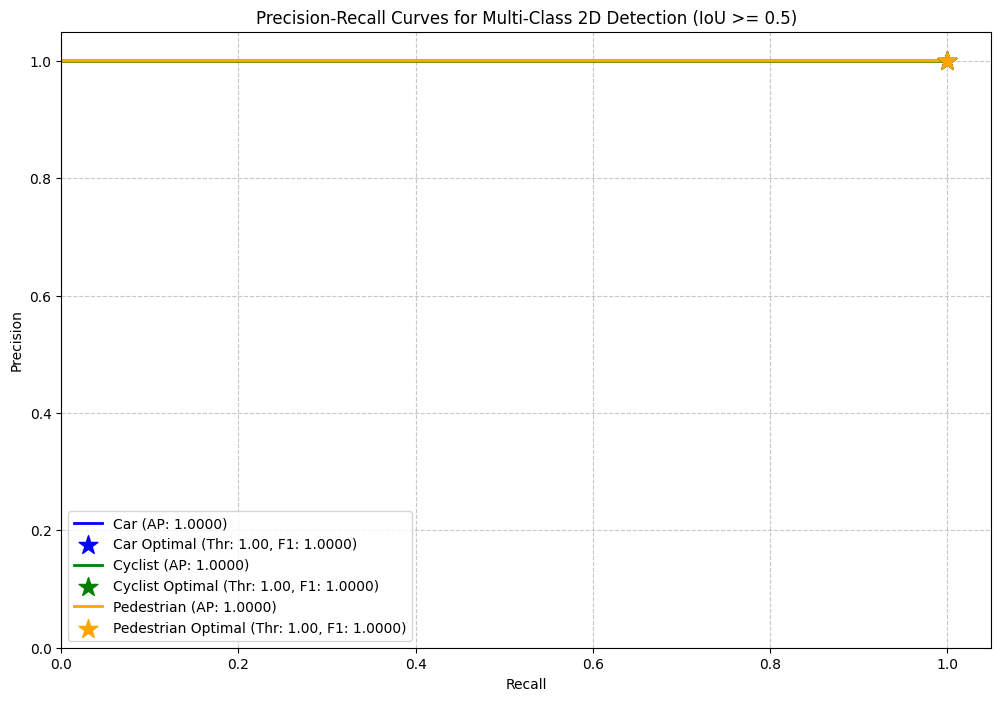


--- Multi-Class 2D Detection Summary (IoU >= 0.5) ---

Class: Car
  Average Precision (AP): 1.0000
  Optimal Confidence Threshold: 1.0000
  Precision at Optimal: 1.0000
  Recall at Optimal: 1.0000
  Max F1-score: 1.0000
  Average IoU at Optimal: 1.0000

Class: Cyclist
  Average Precision (AP): 1.0000
  Optimal Confidence Threshold: 1.0000
  Precision at Optimal: 1.0000
  Recall at Optimal: 1.0000
  Max F1-score: 1.0000
  Average IoU at Optimal: 1.0000

Class: Pedestrian
  Average Precision (AP): 1.0000
  Optimal Confidence Threshold: 1.0000
  Precision at Optimal: 1.0000
  Recall at Optimal: 1.0000
  Max F1-score: 1.0000
  Average IoU at Optimal: 1.0000


In [ ]:
import matplotlib.pyplot as plt

classes_to_evaluate = ['Car', 'Cyclist', 'Pedestrian']
all_class_metrics = {}

plt.figure(figsize=(12, 8))
colors = ['blue', 'green', 'orange']

for idx, cls in enumerate(classes_to_evaluate):
    print(f"Evaluating class: {cls}...")
    # Extract matches for the specific class
    matches = extract_prediction_matches(pred_infos, gt_infos, target_class=cls, iou_threshold=0.5)

    # Evaluate metrics
    metrics = evaluate_class_2d(cls, matches, gt_infos)
    all_class_metrics[cls] = metrics

    if metrics['recall_array'].size > 0 and metrics['precision_array'].size > 0:
        # Plot PR curve
        plt.plot(metrics['recall_array'], metrics['precision_array'], color=colors[idx],
                 label=f"{cls} (AP: {metrics['AP']:.4f})", linewidth=2)

        # Highlight optimal threshold
        plt.scatter(metrics['optimal_recall'], metrics['optimal_precision'], marker='*', s=200, color=colors[idx], zorder=5,
                    label=f"{cls} Optimal (Thr: {metrics['optimal_threshold']:.2f}, F1: {metrics['optimal_f1']:.4f})")
    else:
        print(f"No valid data to plot for {cls}.")

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves for Multi-Class 2D Detection (IoU >= 0.5)')
plt.legend(loc='lower left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim(0, 1.05)
plt.ylim(0, 1.05)
plt.show()

# Print summary
print("\n--- Multi-Class 2D Detection Summary (IoU >= 0.5) ---")
for cls, m in all_class_metrics.items():
    print(f"\nClass: {cls}")
    print(f"  Average Precision (AP): {m['AP']:.4f}")
    print(f"  Optimal Confidence Threshold: {m['optimal_threshold']:.4f}")
    print(f"  Precision at Optimal: {m['optimal_precision']:.4f}")
    print(f"  Recall at Optimal: {m['optimal_recall']:.4f}")
    print(f"  Max F1-score: {m['optimal_f1']:.4f}")
    print(f"  Average IoU at Optimal: {m['optimal_avg_iou']:.4f}")